Successfully loaded 'non_linear.csv'.

--- Original Data ---
          X  Class
0 -2.251643      0
1 -2.569132      0
2 -2.176156      0
3 -1.738485      0
4 -2.617077      0




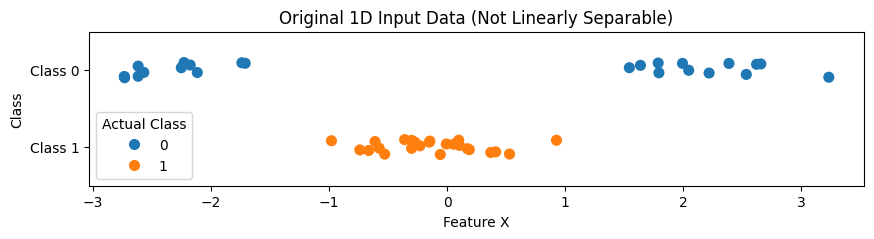

--- Data after Polynomial Transformation ---
          X  Class  X_squared
0 -2.251643      0   5.069896
1 -2.569132      0   6.600440
2 -2.176156      0   4.735654
3 -1.738485      0   3.022330
4 -2.617077      0   6.849090




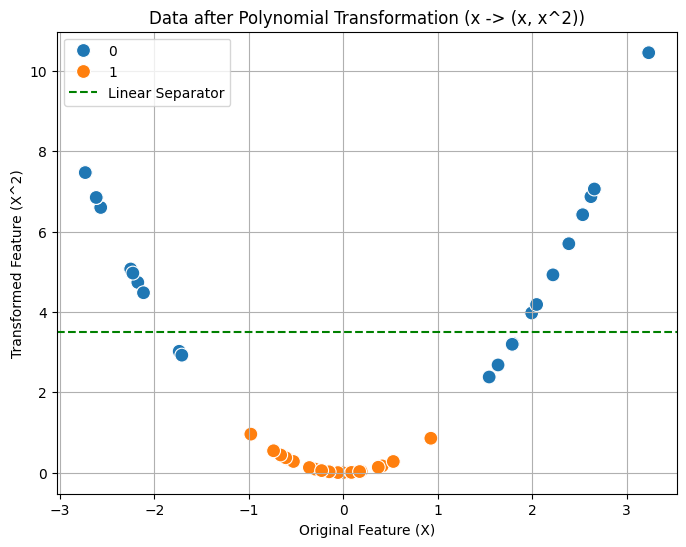

--- Data after RBF-like Transformation ---
          X  RBF_landmark1  RBF_landmark2  Class
0 -2.251643       0.981182       0.004414      0
1 -2.569132       0.907399       0.001905      0
2 -2.176156       0.990734       0.005342      0
3 -1.738485       0.979692       0.015103      0
4 -2.617077       0.892048       0.001670      0




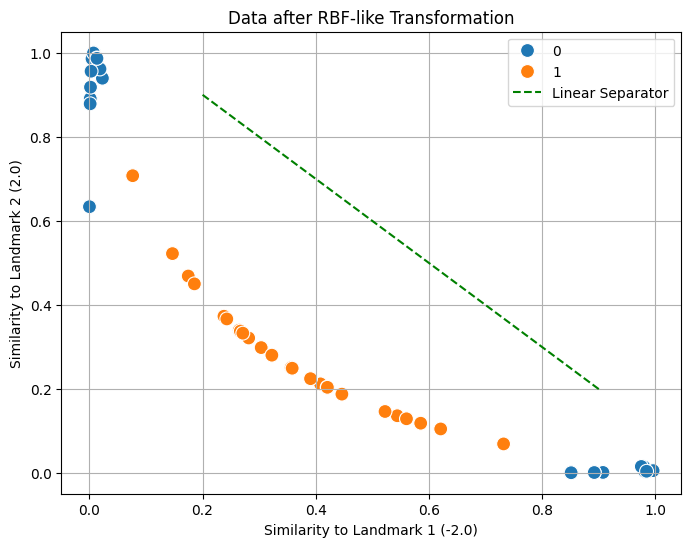

--- Data after Sigmoid-like Transformation ---
          X  X_sigmoid  Class
0 -2.251643  -0.946942      0
1 -2.569132  -0.967734      0
2 -2.176156  -0.940334      0
3 -1.738485  -0.883344      0
4 -2.617077  -0.970081      0




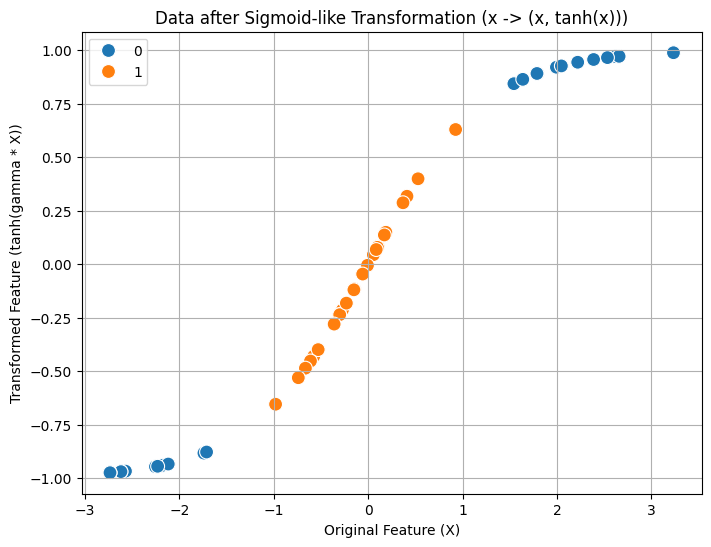

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Read and Prepare the Data ---
path='/content/drive/MyDrive/MScDS&AI/SVM/'
# Read the previously saved non-linear data
df = pd.read_csv(path+'non_linear.csv')
print("Successfully loaded 'non_linear.csv'.\n")
print("--- Original Data ---")
print(df.head())
print("\n")


# --- 2. Visualize the Original 1D Data ---

# This plot shows that the data is not linearly separable in one dimension.
plt.figure(figsize=(10, 2))
plt.title('Original 1D Input Data (Not Linearly Separable)')
sns.stripplot(x='X', y='Class', data=df, hue='Class', orient='h', s=8, jitter=0.1)
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel('Feature X')
plt.ylabel('Class')
plt.legend(title='Actual Class')
plt.show()


# --- 3. Apply and Visualize Polynomial Transformation ---

# The core idea of a polynomial kernel is to add polynomial features.
# For a 2nd-degree polynomial, we can map our 1D data (x) to 2D data (x, x^2).
df['X_squared'] = df['X']**2

print("--- Data after Polynomial Transformation ---")
print(df.head())
print("\n")

# Plot the transformed data
plt.figure(figsize=(8, 6))
plt.title('Data after Polynomial Transformation (x -> (x, x^2))')
sns.scatterplot(x='X', y='X_squared', data=df, hue='Class', s=100)
plt.xlabel('Original Feature (X)')
plt.ylabel('Transformed Feature (X^2)')
plt.axhline(y=3.5, color='g', linestyle='--', label='Linear Separator')
plt.legend()
plt.grid(True)
plt.show()


# --- 4. Apply and Visualize RBF-like Transformation ---

# The RBF kernel works by mapping data based on its distance to landmark points.
# Let's choose two landmarks, one for each class cluster.
landmark1 = -2.0
landmark2 = 2.0
gamma = 0.3 # A hyperparameter for RBF

# Create new features based on the RBF formula: exp(-gamma * ||x - landmark||^2)
df['RBF_landmark1'] = np.exp(-gamma * (df['X'] - landmark1)**2)
df['RBF_landmark2'] = np.exp(-gamma * (df['X'] - landmark2)**2)

print("--- Data after RBF-like Transformation ---")
print(df[['X', 'RBF_landmark1', 'RBF_landmark2', 'Class']].head())
print("\n")

# Plot the transformed data
plt.figure(figsize=(8, 6))
plt.title('Data after RBF-like Transformation')
sns.scatterplot(x='RBF_landmark1', y='RBF_landmark2', data=df, hue='Class', s=100)
plt.xlabel('Similarity to Landmark 1 (-2.0)')
plt.ylabel('Similarity to Landmark 2 (2.0)')
# A diagonal line can now separate the classes
plt.plot([0.9, 0.2], [0.2, 0.9], color='g', linestyle='--', label='Linear Separator')
plt.legend()
plt.grid(True)
plt.show()


# --- 5. Apply and Visualize Sigmoid-like Transformation ---

# The sigmoid kernel uses the hyperbolic tangent function.
# We can create a new dimension by applying this function to the original feature.
gamma_sig = 0.8
df['X_sigmoid'] = np.tanh(gamma_sig * df['X'])

print("--- Data after Sigmoid-like Transformation ---")
print(df[['X', 'X_sigmoid', 'Class']].head())
print("\n")

# Plot the transformed data
plt.figure(figsize=(8, 6))
plt.title('Data after Sigmoid-like Transformation (x -> (x, tanh(x)))')
sns.scatterplot(x='X', y='X_sigmoid', data=df, hue='Class', s=100)
plt.xlabel('Original Feature (X)')
plt.ylabel('Transformed Feature (tanh(gamma * X))')
# The data is still not easily separable with a straight line in this simple case,
# highlighting that not all transformations work for all data.
plt.legend()
plt.grid(True)
plt.show()
